# Dataset Initialization Benchmark

This notebook benchmarks dataset initialization time as the number of episodes scales up.

Tests both:
- **Zarr**: Custom zarr-based dataset format
- **LeRobot**: LeRobot dataset format

Scaling: 1, 10, 100, 1000, ... episodes

In [25]:
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import ConcatDataset

from egomimic.rldb.zarr.zarr_dataset import ZarrDataset
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset

## Configuration

Set your dataset paths here:

In [26]:
# Dataset paths
ZARR_PATH = Path("/home/ryan/Code/EgoVerse/egomimic/rldb/zarr/zarr/prestack/1ts")  # Update this
LEROBOT_PATH = Path("//home/ryan/Code/EgoVerse/egomimic/rldb/zarr/lerobot/100")  # Update this

# Benchmarking configuration
EPISODE_COUNTS = [1, 10, 100]  # Scale up to this many episodes

# Control which datasets to test
TEST_ZARR = True
TEST_LEROBOT = True

## Helper Functions

In [27]:
def get_zarr_episode_count(root: Path) -> int:
    """Get number of available Zarr episodes."""
    root = root.resolve()
    
    # Check both new layout (episodes in root) and legacy layout (episodes in data/)
    search_dir = root
    data_dir = root / "data"
    if data_dir.exists() and any(
        p.name.startswith("episode_") and p.name.endswith(".zarr")
        for p in data_dir.iterdir() if p.is_dir()
    ):
        search_dir = data_dir
    
    if not search_dir.exists():
        return 0
    
    episode_indices = []
    for ep_path in search_dir.iterdir():
        if not ep_path.is_dir():
            continue
        name = ep_path.name
        if not name.startswith("episode_") or not name.endswith(".zarr"):
            continue
        try:
            ep_idx = int(name.replace("episode_", "").replace(".zarr", ""))
            episode_indices.append(ep_idx)
        except ValueError:
            continue
    
    return len(episode_indices)


def get_lerobot_episode_dirs(root: Path, max_episodes: int | None = None) -> list[Path]:
    """Get sorted list of LeRobot episode directories."""
    root = root.resolve()
    
    # Check if this is a single-episode dataset
    info_path = root / "meta" / "info.json"
    if info_path.exists():
        return [root]
    
    # Multi-episode dataset: find all episode subdirectories
    episode_dirs = [
        path
        for path in sorted(root.iterdir())
        if path.is_dir() and (path / "meta" / "info.json").exists()
    ]
    
    if max_episodes is not None:
        episode_dirs = episode_dirs[:max_episodes]
    
    return episode_dirs


def benchmark_zarr_init(zarr_path: Path, num_episodes: int) -> dict:
    """Benchmark Zarr dataset initialization time."""
    start = time.perf_counter()
    dataset = ZarrDataset(
        repo_id=zarr_path.name,
        root=zarr_path,
        episodes=list(range(num_episodes)) if num_episodes > 0 else None,
    )
    elapsed = time.perf_counter() - start
    
    return {
        "num_episodes": num_episodes,
        "total_frames": len(dataset),
        "init_time": elapsed,
    }


def benchmark_lerobot_init(lerobot_path: Path, num_episodes: int) -> dict:
    """Benchmark LeRobot dataset initialization time."""
    episode_dirs = get_lerobot_episode_dirs(lerobot_path, max_episodes=num_episodes)
    actual_num_episodes = len(episode_dirs)
    
    start = time.perf_counter()
    
    if len(episode_dirs) == 1 and episode_dirs[0] == lerobot_path:
        # Single episode dataset
        dataset = LeRobotDataset(
            repo_id=lerobot_path.name,
            root=lerobot_path,
            local_files_only=True,
        )
    else:
        # Multi-episode dataset
        datasets = []
        for episode_dir in episode_dirs:
            datasets.append(
                LeRobotDataset(
                    repo_id=f"{lerobot_path.name}/{episode_dir.name}",
                    root=episode_dir,
                    local_files_only=True,
                )
            )
        dataset = ConcatDataset(datasets)
    
    elapsed = time.perf_counter() - start
    
    return {
        "num_episodes": actual_num_episodes,
        "total_frames": len(dataset),
        "init_time": elapsed,
    }


def print_results_table(zarr_results: list[dict] | None, lerobot_results: list[dict] | None):
    """Print benchmark results in a formatted table."""
    print("\n" + "=" * 80)
    print(f"{'Episodes':<12} {'Total Frames':<15} {'Init Time':<15}")
    print("=" * 80)
    
    if zarr_results:
        print("\n[ZARR]")
        for result in zarr_results:
            print(
                f"{result['num_episodes']:<12} "
                f"{result['total_frames']:<15,} "
                f"{result['init_time']:.3f}s"
            )
    
    if lerobot_results:
        print("\n[LeRobot]")
        for result in lerobot_results:
            print(
                f"{result['num_episodes']:<12} "
                f"{result['total_frames']:<15,} "
                f"{result['init_time']:.3f}s"
            )
    
    print("=" * 80)

## Run Benchmarks

In [28]:
# Validate paths
if TEST_ZARR and not ZARR_PATH.exists():
    print(f"Warning: Zarr path does not exist: {ZARR_PATH}")
    TEST_ZARR = False

if TEST_LEROBOT and not LEROBOT_PATH.exists():
    print(f"Warning: LeRobot path does not exist: {LEROBOT_PATH}")
    TEST_LEROBOT = False

# Determine available episodes
if TEST_ZARR:
    max_zarr_episodes = get_zarr_episode_count(ZARR_PATH)
    print(f"Zarr dataset has {max_zarr_episodes} episodes")

if TEST_LEROBOT:
    lerobot_episode_dirs = get_lerobot_episode_dirs(LEROBOT_PATH)
    max_lerobot_episodes = len(lerobot_episode_dirs)
    print(f"LeRobot dataset has {max_lerobot_episodes} episodes")

Zarr dataset has 100 episodes
LeRobot dataset has 100 episodes


In [29]:
# Run benchmarks
zarr_results = []
lerobot_results = []

for num_episodes in EPISODE_COUNTS:
    print(f"\nBenchmarking with {num_episodes} episode(s)...")
    
    if TEST_ZARR:
        if num_episodes <= max_zarr_episodes:
            print(f"  Zarr: ", end="", flush=True)
            result = benchmark_zarr_init(ZARR_PATH, num_episodes)
            zarr_results.append(result)
            print(f"{result['init_time']:.3f}s")
        else:
            print(f"  Zarr: Skipped (only {max_zarr_episodes} episodes available)")
    
    if TEST_LEROBOT:
        if num_episodes <= max_lerobot_episodes:
            print(f"  LeRobot: ", end="", flush=True)
            result = benchmark_lerobot_init(LEROBOT_PATH, num_episodes)
            lerobot_results.append(result)
            print(f"{result['init_time']:.3f}s")
        else:
            print(f"  LeRobot: Skipped (only {max_lerobot_episodes} episodes available)")

print("\n✓ Benchmarking complete!")


Benchmarking with 1 episode(s)...
  Zarr: 0.011s
  LeRobot: 0.316s

Benchmarking with 10 episode(s)...
  Zarr: 0.069s
  LeRobot: 1.660s

Benchmarking with 100 episode(s)...
  Zarr: 0.604s
  LeRobot: 16.420s

✓ Benchmarking complete!


## Results Table

In [30]:
print_results_table(
    zarr_results if zarr_results else None,
    lerobot_results if lerobot_results else None
)


Episodes     Total Frames    Init Time      

[ZARR]
1            1,467           0.011s
10           10,489          0.069s
100          104,890         0.604s

[LeRobot]
1            746             0.316s
10           7,460           1.660s
100          74,600          16.420s


## Visualization

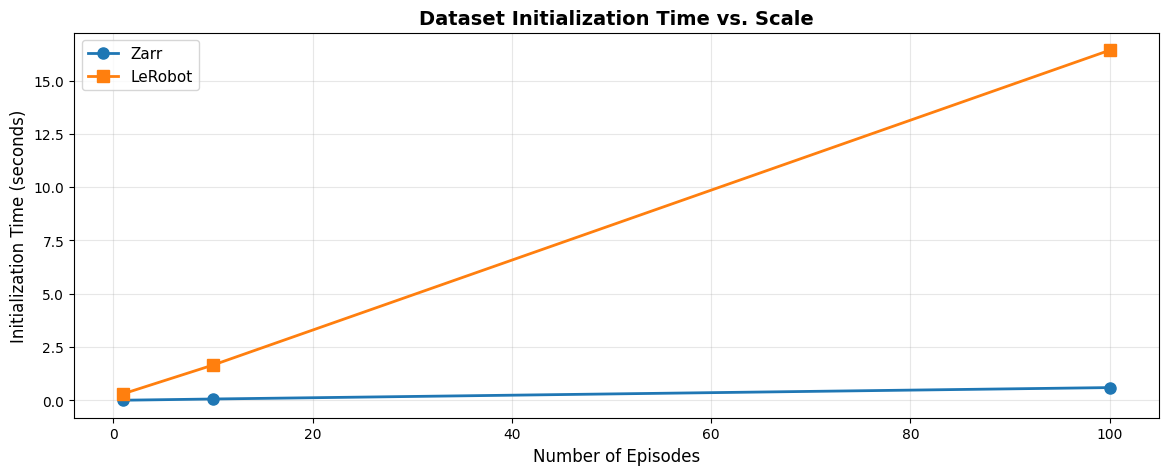

In [36]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot 1: Initialization time vs. number of episodes
if zarr_results:
    episodes = [r['num_episodes'] for r in zarr_results]
    times = [r['init_time'] for r in zarr_results]
    ax1.plot(episodes, times, marker='o', label='Zarr', linewidth=2, markersize=8)

if lerobot_results:
    episodes = [r['num_episodes'] for r in lerobot_results]
    times = [r['init_time'] for r in lerobot_results]
    ax1.plot(episodes, times, marker='s', label='LeRobot', linewidth=2, markersize=8)

ax1.set_xlabel('Number of Episodes', fontsize=12)
ax1.set_ylabel('Initialization Time (seconds)', fontsize=12)
ax1.set_title('Dataset Initialization Time vs. Scale', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=11)

## Analysis

Key observations:
- **Left plot**: Shows how initialization time grows with dataset size (log-log scale)
- **Right plot**: Shows time per episode - indicates whether initialization scales linearly or has overhead
- **Speedup table**: Direct comparison of initialization performance between formats